<a href="https://colab.research.google.com/github/MatteoZancanaro-5758278/IB9AU-2026/blob/main/Task_14_RAG_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Key Takeaway

I've learned how to build a Page-Wise Visual RAG pipeline that embeds each PDF page as a vector, retrieves the most similar page to a query, renders it as an image, and sends it to a Vision-Language Model (Qwen2.5-VL) to answer visually. Results were mixed — Tasks 1 and 4 were accurate, but Tasks 2 and 3 failed because the retriever landed on the wrong page. To improve this the idea could be to either retrieve the top 3 pages and send all of them to the VLM, or craft more targeted queries using specific table names and keywords that mirror the actual document language rather than natural language questions.

## Step 1: Upgrade Pillow and Restart Runtime

Colab ships with an outdated Pillow version that breaks the embedding model.
You MUST run this cell first, then go to **Runtime → Restart session**.
Do not re-run this cell after restarting — continue from Step 2.

In [1]:
!pip install -qU Pillow
print("✅ Pillow upgraded. Now go to Runtime → Restart session, then continue from Step 2.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 42.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.1.1 which is incompatible.
✅ Pillow upgraded. Now go to Runtime → Restart session, then continue from Step 2.


In [1]:
import torch

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"✅ GPU detected: {gpu_name} ({vram_gb:.1f} GB VRAM)")
else:
    print("❌ NO GPU DETECTED!")
    print("   Go to Runtime → Change runtime type → T4 GPU")
    raise RuntimeError("GPU required. Please switch to T4 GPU and re-run.")

!pip install -qU transformers accelerate
!pip install -qU llama-index-core llama-index-readers-file llama-index-embeddings-huggingface pypdf
!pip install -qU pdf2image
!apt-get install -q poppler-utils

print("✅ All dependencies installed.")

✅ GPU detected: Tesla T4 (15.6 GB VRAM)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 117.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 94.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.7/333.7 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.5/110.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 14.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
Reading package lists...
Building dependency tree...
Reading state information...
The follo

### Step 3: Upload the AstraZeneca PDF

Upload the file `AstraZeneca-Q4-2025-earnings.pdf` to this Colab session.
The cell below opens a file picker — select your PDF and wait for the upload to finish.
The file will be placed in Colab's working directory (`/content/`).

In [4]:
from google.colab import files

print("📂 Select your AstraZeneca PDF file...")
uploaded = files.upload()

# Confirm it arrived
import os
PDF_FILE = "AstraZeneca-Q4-2025-earnings.pdf"
if os.path.exists(PDF_FILE):
    size_mb = os.path.getsize(PDF_FILE) / 1e6
    print(f"✅ '{PDF_FILE}' uploaded successfully ({size_mb:.1f} MB)")
else:
    print(f"❌ Could not find '{PDF_FILE}'. Make sure the filename matches exactly.")

📂 Select your AstraZeneca PDF file...


Saving AstraZeneca-Q4-2025-earnings.pdf to AstraZeneca-Q4-2025-earnings.pdf
✅ 'AstraZeneca-Q4-2025-earnings.pdf' uploaded successfully (1.5 MB)


## Step 4: Load the Embedding Model

`all-MiniLM-L6-v2` is a lightweight sentence-transformer that converts text into
384-dimensional vectors. It runs on CPU and needs no API key.

This is used in the **retrieval** step — it reads every page of the PDF, converts
the text to a vector, and stores it so we can later find the most relevant page
for a given query using cosine similarity.

In [5]:
from llama_index.core import SimpleDirectoryReader, VectorStoreIndex, Settings
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")
print("✅ Embedding model loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Embedding model loaded.


## Step 5: Load the Vision-Language Model (VLM)

`Qwen2.5-VL-3B-Instruct` is a 3-billion parameter open-source model that can
**see images and answer questions about them**. At float16 precision it uses
~7.5 GB of VRAM — just within the T4's 15 GB limit.

We explicitly set `device_map="cuda"` to guarantee it loads onto the GPU.
Using `device_map="auto"` can silently fall back to CPU with no warning,
making each query take 5–10 minutes instead of ~15 seconds.

In [6]:
import torch
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor

VLM_MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"

print(f"⏳ Loading {VLM_MODEL_ID} onto GPU...")

vlm_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    VLM_MODEL_ID,
    torch_dtype=torch.float16,
    device_map="cuda"        # explicit — never falls back to CPU
)
vlm_processor = AutoProcessor.from_pretrained(VLM_MODEL_ID)

model_device = next(vlm_model.parameters()).device
print(f"✅ VLM loaded on: {model_device}")

⏳ Loading Qwen/Qwen2.5-VL-3B-Instruct onto GPU...


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ VLM loaded on: cuda:0


## Step 6: Configure LlamaIndex Settings

We tell LlamaIndex to use our local embedding model.
We set `llm = None` because LlamaIndex's built-in LLM slot is for text generation —
we don't need it here since the Qwen VLM handles all answering directly.

In [7]:
Settings.embed_model = embed_model
Settings.llm = None
print("✅ LlamaIndex configured.")

LLM is explicitly disabled. Using MockLLM.
✅ LlamaIndex configured.


## Step 7: Load the PDF and Build the Vector Index

`SimpleDirectoryReader` reads the PDF and creates one Document object per page.
Each document carries metadata including `page_label` — the page number we'll
use later to render the right page as an image.

`VectorStoreIndex` then embeds every page's text and stores the vectors in memory.
The retriever is set to return the single best-matching page (`similarity_top_k=1`).

In [8]:
print(f"📄 Loading '{PDF_FILE}'...")
documents = SimpleDirectoryReader(input_files=[PDF_FILE]).load_data()
print(f"   Loaded {len(documents)} pages.")
print(f"   Sample metadata: {documents[0].metadata}")

print("\n🧠 Building vector index (embedding all pages)...")
index     = VectorStoreIndex.from_documents(documents)
retriever = index.as_retriever(similarity_top_k=1)
print("✅ Index ready — retriever configured to return top-1 page.")

📄 Loading 'AstraZeneca-Q4-2025-earnings.pdf'...
   Loaded 39 pages.
   Sample metadata: {'page_label': '1', 'file_name': 'AstraZeneca-Q4-2025-earnings.pdf', 'file_path': 'AstraZeneca-Q4-2025-earnings.pdf', 'file_type': 'application/pdf', 'file_size': 1545942, 'creation_date': '2026-03-20', 'last_modified_date': '2026-03-20'}

🧠 Building vector index (embedding all pages)...
✅ Index ready — retriever configured to return top-1 page.


## Step 8: The Visual RAG Orchestrator

`query_visual_rag()` is the core function that ties the whole pipeline together.
Here is exactly what happens when you call it with a query:

1. **Retrieve** — LlamaIndex searches the vector index and finds the page whose
   text embedding is closest to the query embedding.
2. **Locate** — The page number is read from the node's metadata.
3. **Render** — `pdf2image` converts that exact PDF page to a PIL image at 150 DPI,
   preserving tables, charts, and layout exactly as printed.
4. **Prompt** — The image and your question are packaged into a structured chat
   message that Qwen2.5-VL understands.
5. **Generate** — The VLM reads the image and generates a text answer.
   `do_sample=False` means deterministic (greedy) output — no randomness,
   so the same query always gives the same answer.

In [9]:
from pdf2image import convert_from_path
from PIL import Image
import torch

def query_visual_rag(query_text, max_new_tokens=256):
    print(f"\n🔎 Query: '{query_text}'")

    # Safety check
    model_device = next(vlm_model.parameters()).device
    if str(model_device) == "cpu":
        print("⚠️  WARNING: VLM is on CPU — this will be very slow.")

    # 1. RETRIEVE — find the best page by text similarity
    nodes = retriever.retrieve(query_text)
    if not nodes:
        return "❌ No relevant page found."

    best_node  = nodes[0]
    page_label = best_node.metadata.get("page_label")
    page_index = int(page_label) - 1 if page_label else 0

    print(f"📍 Best match: Page {page_label}  (similarity score: {best_node.score:.4f})")
    print(f"   Text snippet: {best_node.text[:120]}...")

    # 2. RENDER — convert that PDF page to an image
    print("🖼️  Rendering page as image...")
    pages      = convert_from_path(PDF_FILE,
                                   first_page=page_index + 1,
                                   last_page=page_index + 1,
                                   dpi=150)
    page_image = pages[0]

    # 3. PROMPT — build the Qwen2.5-VL chat message
    print(f"🚀 Sending to VLM (max {max_new_tokens} new tokens)...")
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": page_image},
                {"type": "text",  "text": (
                    f"You are an expert financial analyst reviewing Page {page_label} "
                    "of AstraZeneca's FY and Q4 2025 Earnings Report. "
                    "Answer the following question based strictly on the text, tables, "
                    "and charts visible on this page. "
                    "If numbers appear in a table, quote them exactly. "
                    "If the answer involves a chart, describe the visual trend.\n\n"
                    f"Question: {query_text}"
                )}
            ]
        }
    ]

    # 4. GENERATE — run the VLM
    text_prompt = vlm_processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = vlm_processor(
        text=[text_prompt],
        images=[page_image],
        return_tensors="pt"
    ).to(vlm_model.device)

    with torch.no_grad():
        output_ids = vlm_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,   # deterministic / greedy
            temperature=None,  # must be None when do_sample=False
            top_p=None,
        )

    # Decode only the newly generated tokens (skip the input prompt)
    generated = output_ids[:, inputs["input_ids"].shape[1]:]
    answer    = vlm_processor.batch_decode(generated, skip_special_tokens=True)[0]
    return answer

print("✅ query_visual_rag() is ready.")

✅ query_visual_rag() is ready.


## Task 1 — Revenue Table Extraction

We ask the system about AstraZeneca's top-line revenue figures.
This is a good first test because the answer lives in a structured financial table —
something text-extraction RAG handles poorly (column alignment gets scrambled),
but a VLM reading the rendered page image can interpret correctly.

In [10]:
from IPython.display import display, Markdown

q1 = ("What were AstraZeneca's total Product Sales and Alliance Revenue "
      "for FY 2025, and how did each change compared to FY 2024?")

display(Markdown(f"### Task 1 Query\n> {q1}"))
answer1 = query_visual_rag(q1)
display(Markdown(f"### Answer\n{answer1}"))

### Task 1 Query
> What were AstraZeneca's total Product Sales and Alliance Revenue for FY 2025, and how did each change compared to FY 2024?


🔎 Query: 'What were AstraZeneca's total Product Sales and Alliance Revenue for FY 2025, and how did each change compared to FY 2024?'
📍 Best match: Page 1  (similarity score: 0.7171)
   Text snippet: Summary  Revenue Drivers  R&D Progress  Sustainability  Financial Performance  Financial Statements  Glossary  
 
1 
 
 ...
🖼️  Rendering page as image...
🚀 Sending to VLM (max 256 new tokens)...


### Answer
AstraZeneca's total Product Sales for FY 2025 were $55,733 million, while their Alliance Revenue was $3,067 million. 

For Product Sales:
- Actual: $55,733 million
- % Change: 9%

For Alliance Revenue:
- Actual: $3,067 million
- % Change: 39%

## Task 2 — Regional Revenue Breakdown

This query targets a regional breakdown table. It also tests whether the model
can interpret "constant exchange rates" (CER) — a pharma-specific metric that
strips out currency fluctuation effects to show underlying growth.

In [11]:
q2 = ("Which geographic region had the highest Total Revenue growth in FY 2025, "
      "and what was the growth rate at constant exchange rates?")

display(Markdown(f"### Task 2 Query\n> {q2}"))
answer2 = query_visual_rag(q2)
display(Markdown(f"### Answer\n{answer2}"))

### Task 2 Query
> Which geographic region had the highest Total Revenue growth in FY 2025, and what was the growth rate at constant exchange rates?


🔎 Query: 'Which geographic region had the highest Total Revenue growth in FY 2025, and what was the growth rate at constant exchange rates?'
📍 Best match: Page 34  (similarity score: 0.4615)
   Text snippet: Summary  Revenue Drivers  R&D Progress  Sustainability  Financial Performance  Financial Statements  Glossary  
34 
 
No...
🖼️  Rendering page as image...
🚀 Sending to VLM (max 256 new tokens)...


### Answer
The geographic region with the highest Total Revenue growth in FY 2025, at constant exchange rates, was Emerging Markets, with a growth rate of 11%.

## Task 3 — R&D Pipeline Interpretation

This query targets the regulatory approvals section of the report —
typically a timeline or structured list rather than a financial table.
It tests whether the retriever correctly identifies a non-financial page
and whether the VLM can extract structured facts (drug name + indication) from it.

In [13]:
q3 = ("Which medicines received regulatory approvals in the US between "
      "November 2025 and February 2026, and for what indications?")

display(Markdown(f"### Task 3 Query\n> {q3}"))
answer3 = query_visual_rag(q3)
display(Markdown(f"### Answer\n{answer3}"))

### Task 3 Query
> Which medicines received regulatory approvals in the US between November 2025 and February 2026, and for what indications?


🔎 Query: 'Which medicines received regulatory approvals in the US between November 2025 and February 2026, and for what indications?'
📍 Best match: Page 10  (similarity score: 0.5477)
   Text snippet: BioPharmaceuticals - CVRM 
Farxiga 
FY 2025 
$m 
Total  
Revenue  
% Change        
Actual        CER  
 
 Growth drive...
🖼️  Rendering page as image...
🚀 Sending to VLM (max 256 new tokens)...


### Answer
The information provided does not specify any medicines that received regulatory approvals in the US between November 2025 and February 2026 or their indications. The document focuses on revenue drivers, market performance, and other oncology medicines, but does not mention specific approvals or indications for new drugs.


## Task 4 — Audit Mode Query

Design your own query targeting a *different* section from Tasks 1–3.
Good candidates from the AstraZeneca report:
- Table 10: Reported-to-Core reconciliation
- Table 12: Cash flow statement
- Table 16: Currency sensitivity

The prompt below explicitly instructs the VLM to cite the table and page number
it is reading from. This is called "audit mode" — you are asking the model to
show its working, not just give you a number.

After running it, manually check at least two figures against the PDF to verify accuracy.

In [14]:
# ✏️ Change this query to target a section not covered in Tasks 1–3
q4 = ("From the cash flow statement, what was AstraZeneca's net cash generated "
      "from operating activities in FY 2025, and how does it compare to FY 2024? "
      "Please cite the exact table name and page number your figures come from.")

display(Markdown(f"### Task 4 Query\n> {q4}"))
answer4 = query_visual_rag(q4, max_new_tokens=350)   # slightly longer for audit detail
display(Markdown(f"### Answer\n{answer4}"))

### Task 4 Query
> From the cash flow statement, what was AstraZeneca's net cash generated from operating activities in FY 2025, and how does it compare to FY 2024? Please cite the exact table name and page number your figures come from.


🔎 Query: 'From the cash flow statement, what was AstraZeneca's net cash generated from operating activities in FY 2025, and how does it compare to FY 2024? Please cite the exact table name and page number your figures come from.'
📍 Best match: Page 20  (similarity score: 0.6974)
   Text snippet: Summary  Revenue Drivers  R&D Progress  Sustainability  Financial Performance  Financial Statements  Glossary  
20 
 
Ca...
🖼️  Rendering page as image...
🚀 Sending to VLM (max 350 new tokens)...


### Answer
From the cash flow statement, AstraZeneca's net cash generated from operating activities in FY 2025 was $14,575m, while in FY 2024 it was $11,861m. This represents a change of $2,714m. The information is derived from Table 12: Cash Flow summary: FY 2025 on page 20 of the report.

## Inspect the Retrieved Pages

It is good practice to look at the actual page the retriever selected.
This lets you confirm the right section was found — or diagnose why
the VLM gave a wrong answer (it may have been sent the wrong page).

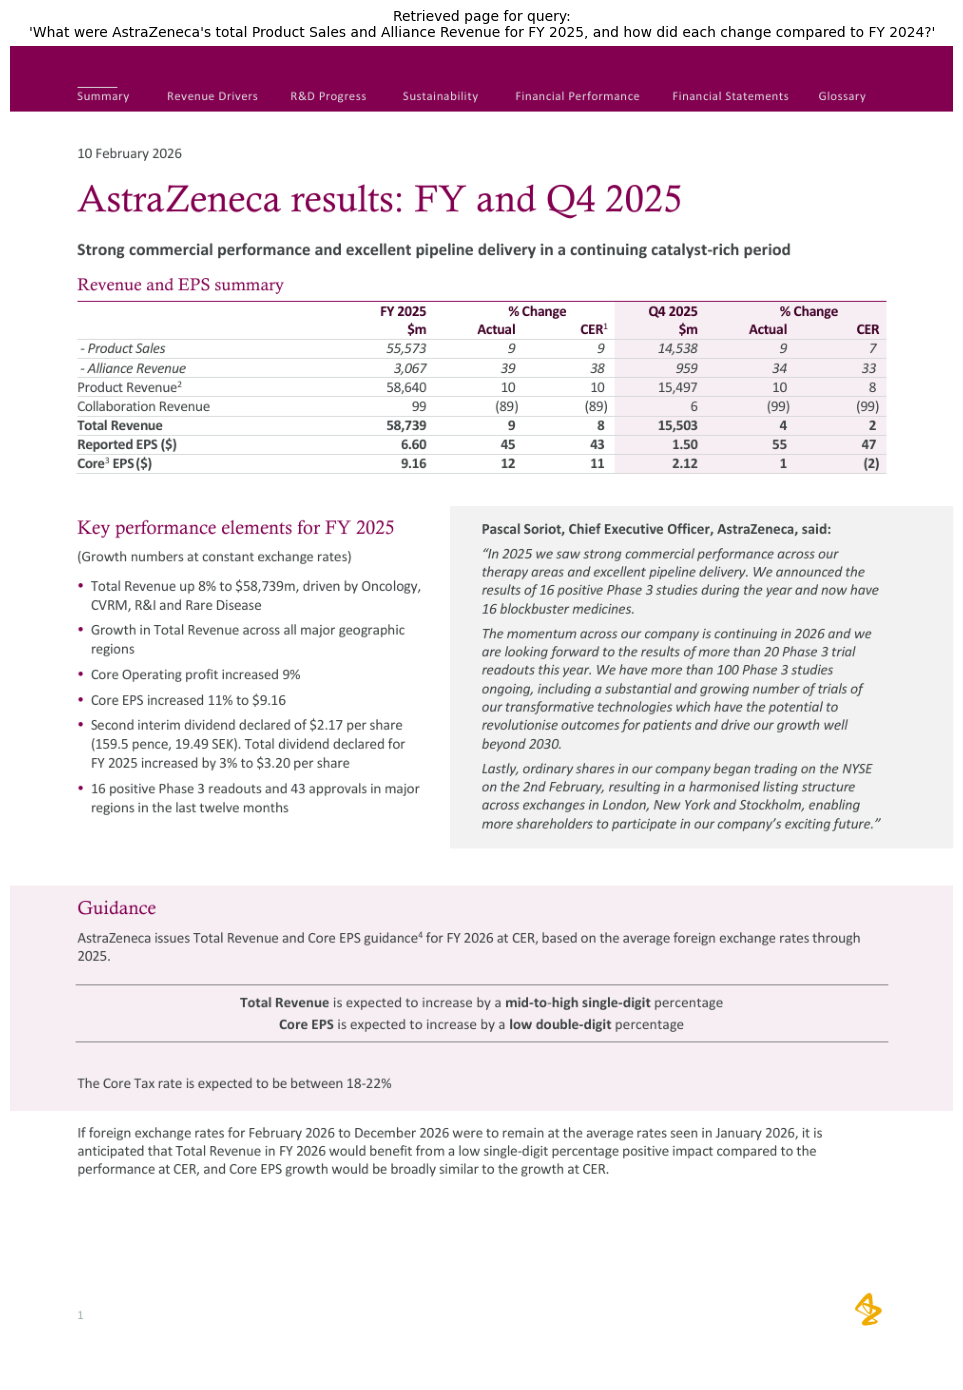

In [15]:
import matplotlib.pyplot as plt
from pdf2image import convert_from_path

def show_retrieved_page(query_text):
    nodes      = retriever.retrieve(query_text)
    page_label = nodes[0].metadata.get("page_label")
    page_index = int(page_label) - 1
    pages      = convert_from_path(PDF_FILE,
                                   first_page=page_index + 1,
                                   last_page=page_index + 1,
                                   dpi=120)
    plt.figure(figsize=(10, 14))
    plt.imshow(pages[0])
    plt.title(f"Retrieved page for query:\n'{query_text}'", fontsize=10)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# Inspect the page retrieved for Task 1
show_retrieved_page(q1)

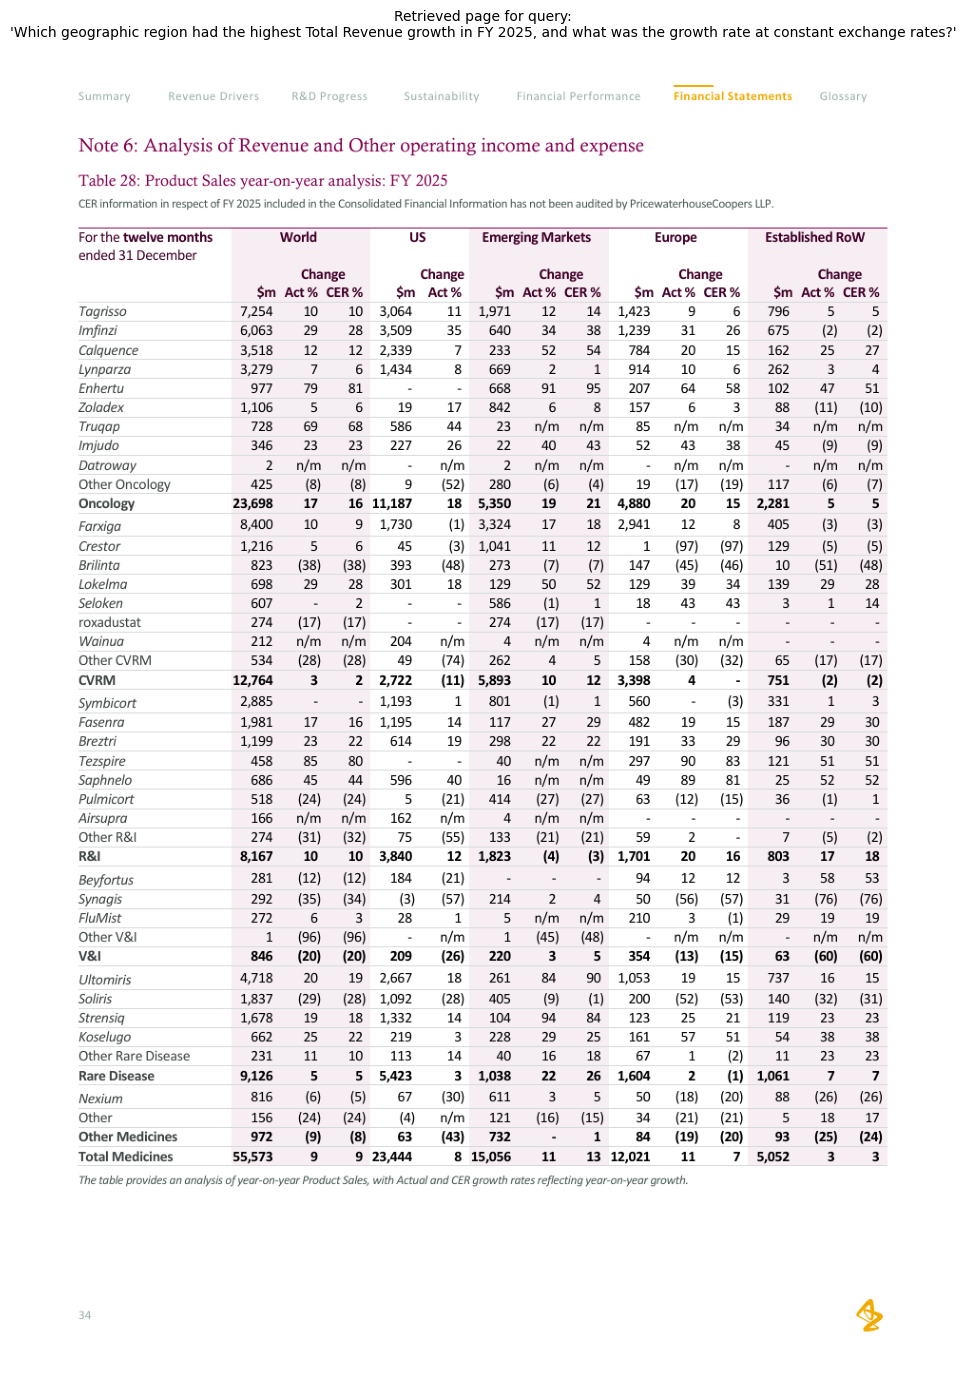

In [16]:
import matplotlib.pyplot as plt
from pdf2image import convert_from_path

def show_retrieved_page(query_text):
    nodes      = retriever.retrieve(query_text)
    page_label = nodes[0].metadata.get("page_label")
    page_index = int(page_label) - 1
    pages      = convert_from_path(PDF_FILE,
                                   first_page=page_index + 1,
                                   last_page=page_index + 1,
                                   dpi=120)
    plt.figure(figsize=(10, 14))
    plt.imshow(pages[0])
    plt.title(f"Retrieved page for query:\n'{query_text}'", fontsize=10)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# Inspect the page retrieved for Task 1
show_retrieved_page(q2)

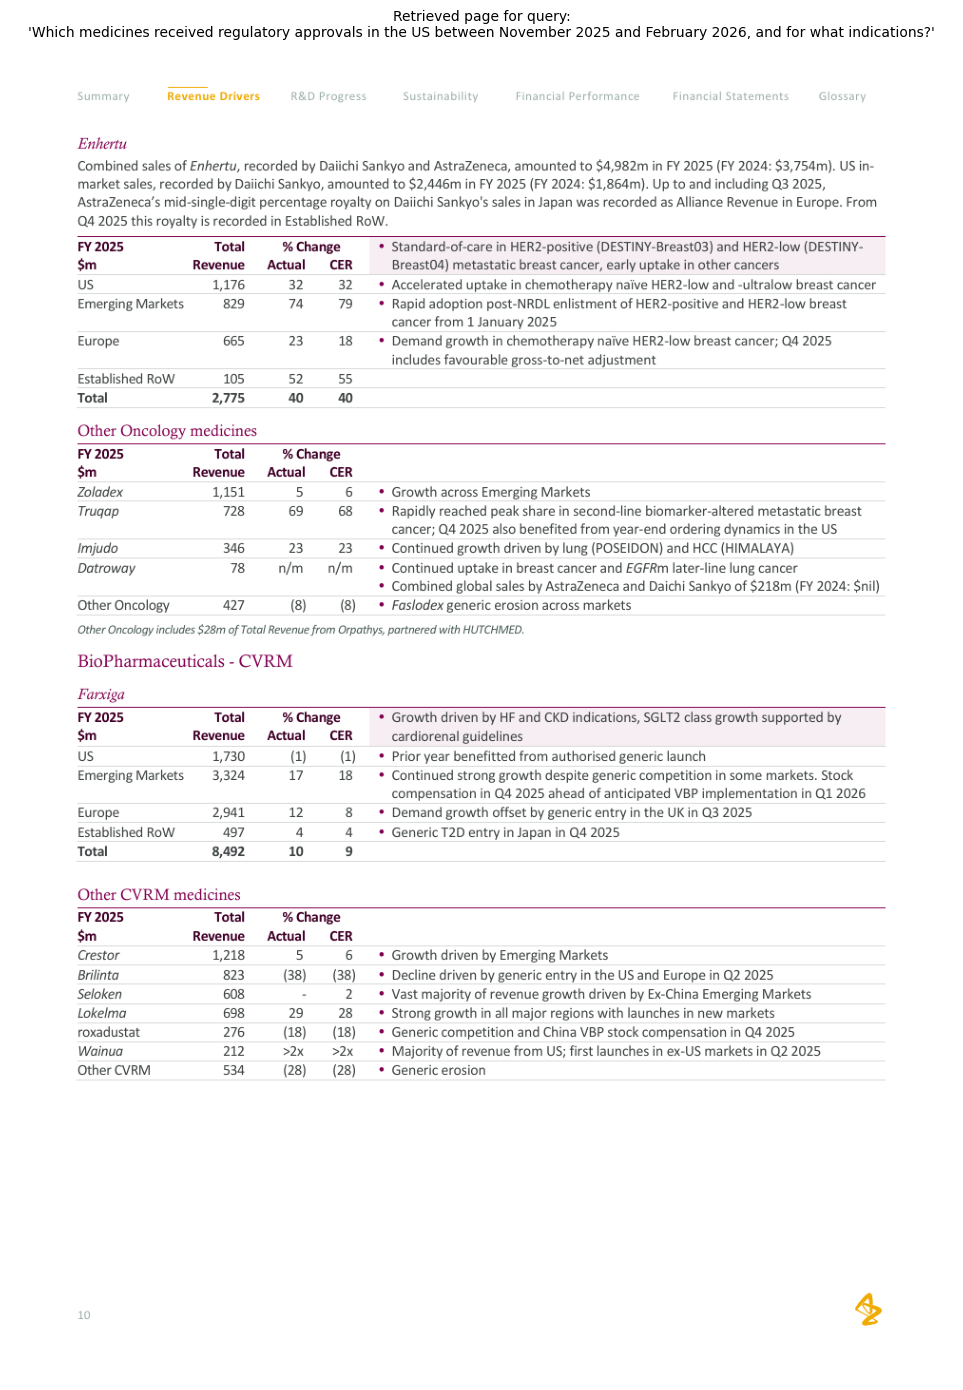

In [17]:
import matplotlib.pyplot as plt
from pdf2image import convert_from_path

def show_retrieved_page(query_text):
    nodes      = retriever.retrieve(query_text)
    page_label = nodes[0].metadata.get("page_label")
    page_index = int(page_label) - 1
    pages      = convert_from_path(PDF_FILE,
                                   first_page=page_index + 1,
                                   last_page=page_index + 1,
                                   dpi=120)
    plt.figure(figsize=(10, 14))
    plt.imshow(pages[0])
    plt.title(f"Retrieved page for query:\n'{query_text}'", fontsize=10)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# Inspect the page retrieved for Task 1
show_retrieved_page(q3)

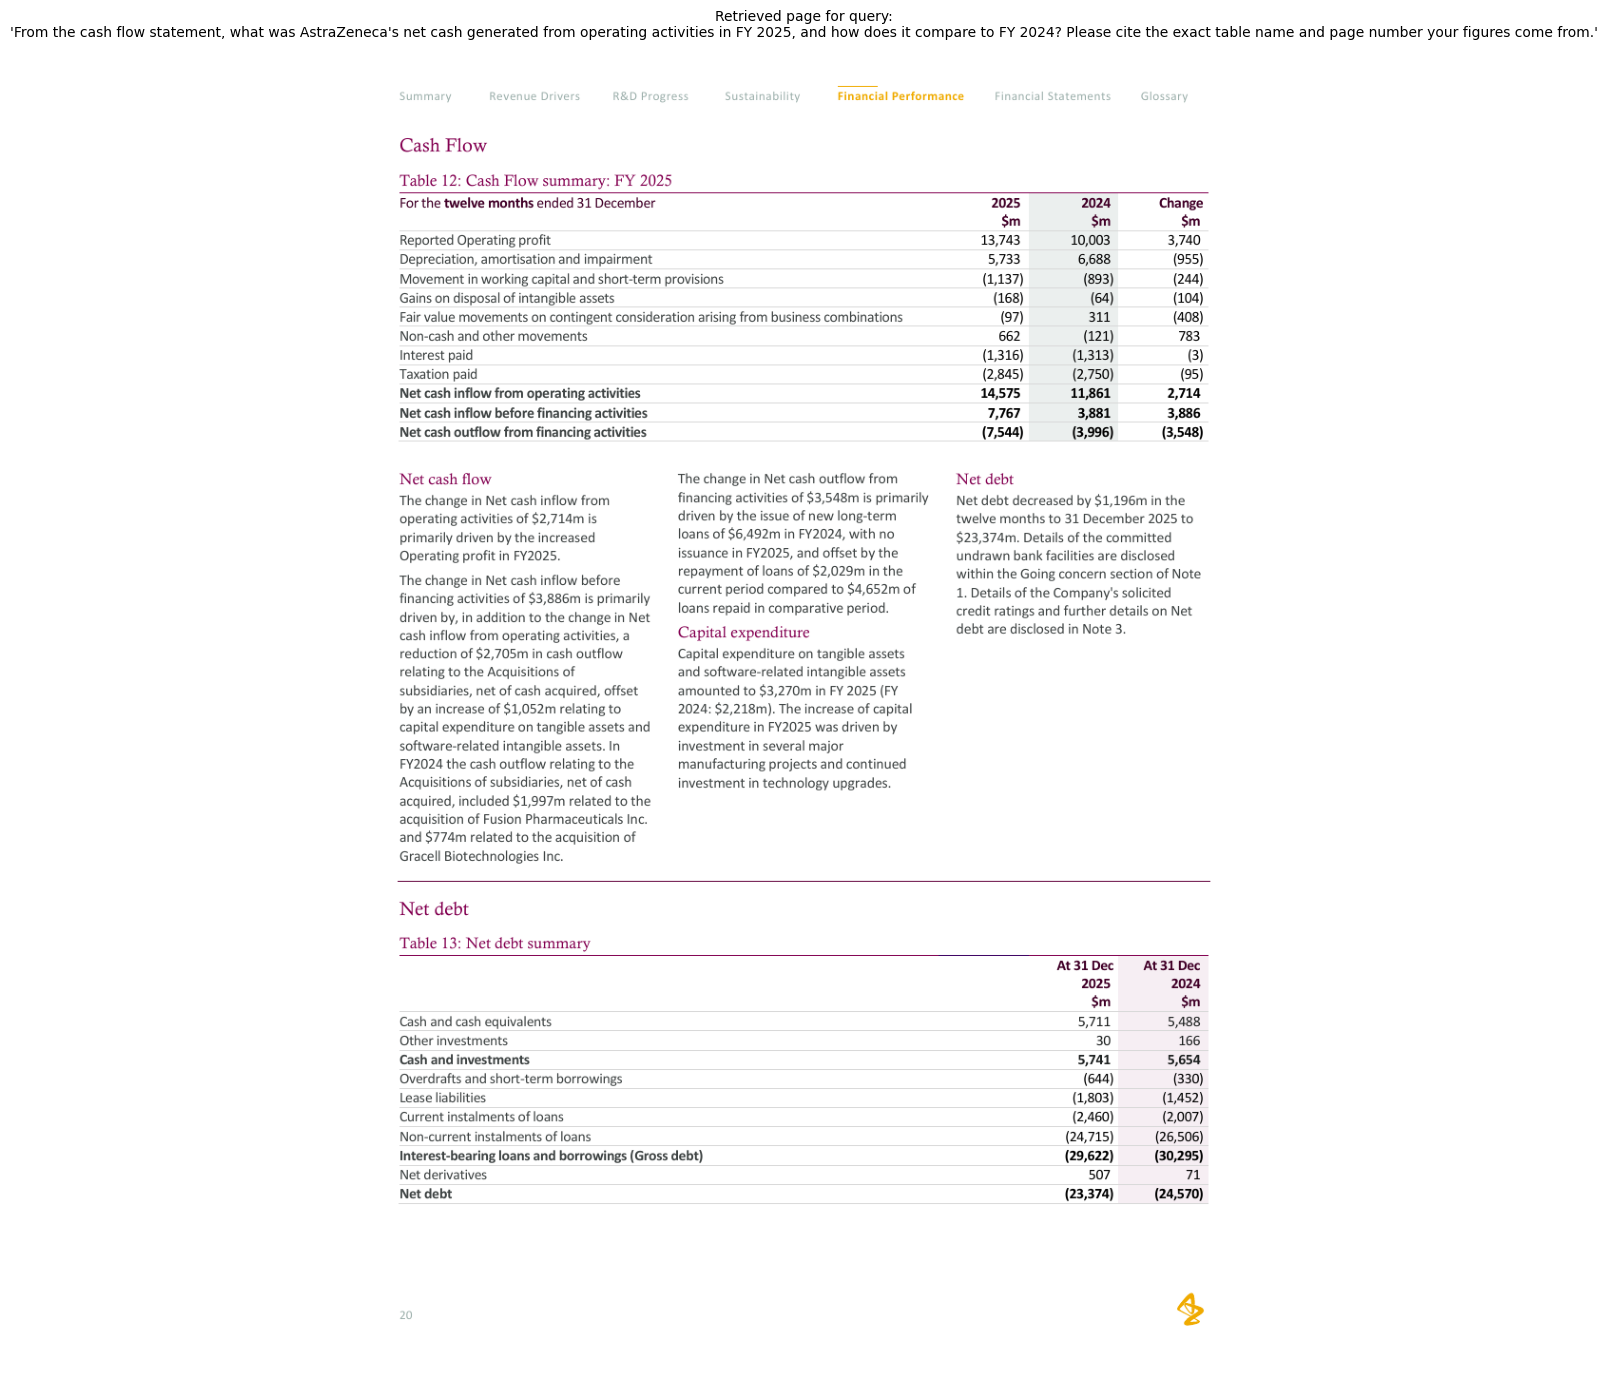

In [18]:
import matplotlib.pyplot as plt
from pdf2image import convert_from_path

def show_retrieved_page(query_text):
    nodes      = retriever.retrieve(query_text)
    page_label = nodes[0].metadata.get("page_label")
    page_index = int(page_label) - 1
    pages      = convert_from_path(PDF_FILE,
                                   first_page=page_index + 1,
                                   last_page=page_index + 1,
                                   dpi=120)
    plt.figure(figsize=(10, 14))
    plt.imshow(pages[0])
    plt.title(f"Retrieved page for query:\n'{query_text}'", fontsize=10)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# Inspect the page retrieved for Task 1
show_retrieved_page(q4)